# LSTM (Tensorflow)

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 11 11:26:24 2025

@author: Karishini
"""

# Financial prediction and analysis

import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

df = pd.read_excel('/content/Transformed_dataset_own.xlsx',
                   sheet_name="Sheet2 (Karish digital)")

# Concatenating date and time columns into a single column 'Datetime'
df['Datetime'] = df['Date'].astype(str) + " " + df['Time'].astype(str)
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Extract only therecords of expenses
df_expenses = df[df['Money flow'] == "Expense"]
df_expenses = df_expenses.sort_values(by='Datetime')

# Extract only date and amount of the expense records
df_expenses = df_expenses[['Datetime','Amount']]

# Set the datetime as index so that we can extract the total daily/monthly expense
df_expenses.set_index('Datetime', inplace=True)

# Calculate the daily expenses
daily_expense_df = df_expenses.resample('D').sum()

# Calculate the monthly expenses
monthly_expense_df = df_expenses.resample('ME').sum()

# Splitting the data for training and testing
split_index = int(0.8 * len(daily_expense_df))
train_daily_df = daily_expense_df[:split_index]
test_daily_df = daily_expense_df[split_index:]

# Creating the sequences of expenses in the past to predict the future expense
def create_sequence(data, window_size):
    # X contains the sequences of past expenses
    # y contains the next day's / month's expense
    data_np = data['Amount'].to_numpy()
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data_np[i-window_size:i])
        y.append(data_np[i])
    X = np.array(X)
    y = np.array(y)
    return X, y

# Define the window sizes for daily predictions and monthly predictions
daily_window_size = 7
monthly_window_size = 3

# Create the train and test sequences for daily predictions
X_train_daily, y_train_daily = create_sequence(train_daily_df, daily_window_size)
X_test_daily, y_test_daily = create_sequence(test_daily_df, daily_window_size)

# Feature Engineering
df_expenses['Day_of_Week'] = df_expenses.index.dayofweek
df_expenses['Month'] = df_expenses.index.month
#df_expenses['Is_Holiday'] = df_expenses.index.isin(holidays)  # Assuming you have a list of holidays

# Rolling Statistics
df_expenses['Rolling_Mean_7'] = df_expenses['Amount'].rolling(window=7).mean()
df_expenses['Rolling_Std_7'] = df_expenses['Amount'].rolling(window=7).std()

# Lag Features
df_expenses['Lag_1'] = df_expenses['Amount'].shift(1)
df_expenses['Lag_7'] = df_expenses['Amount'].shift(7)

# Drop NaN values created by rolling and lag features
df_expenses = df_expenses.dropna()

# Splitting the data for training and testing
split_index = int(0.8 * len(df_expenses))
train_df = df_expenses[:split_index]
test_df = df_expenses[split_index:]

# Creating sequences with additional features
def create_sequence_with_features(data, window_size):
    data_np = data[['Amount', 'Day_of_Week', 'Month', 'Rolling_Mean_7', 'Rolling_Std_7', 'Lag_1', 'Lag_7']].to_numpy()
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data_np[i-window_size:i, :])
        y.append(data_np[i, 0])  # Assuming 'Amount' is the first column
    X = np.array(X)
    y = np.array(y)
    return X, y

# Create the train and test sequences with additional features
X_train, y_train = create_sequence_with_features(train_df, daily_window_size)
X_test, y_test = create_sequence_with_features(test_df, daily_window_size)

# Define and compile the LSTM model with additional features
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(daily_window_size, X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test), verbose=1)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Plotting the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_df.index[daily_window_size:], y_test, label='Actual', color='blue')  # Actual values
plt.plot(test_df.index[daily_window_size:], y_pred, label='Predicted', color='red', linestyle='--')  # Predicted values
plt.title('Actual vs Predicted Daily Expenses')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the model
loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/Transformed_dataset_own.xlsx'

# Hybrid CNN-LSTM

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 47163.8672 - val_loss: 163066.2656
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 49952.6562 - val_loss: 162692.6719
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 86015.2109 - val_loss: 161893.5781
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 37879.6328 - val_loss: 160894.0156
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 32728.2637 - val_loss: 159728.9688
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 42733.6523 - val_loss: 158700.5938
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 46402.4883 - val_loss: 157798.1875
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 47086.3242 - val_loss: 156903.2500
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 47068.9688 - val_loss: 156064.5312
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 34685.6328 - val_loss: 155294.2969
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 34583.5312 - val_loss

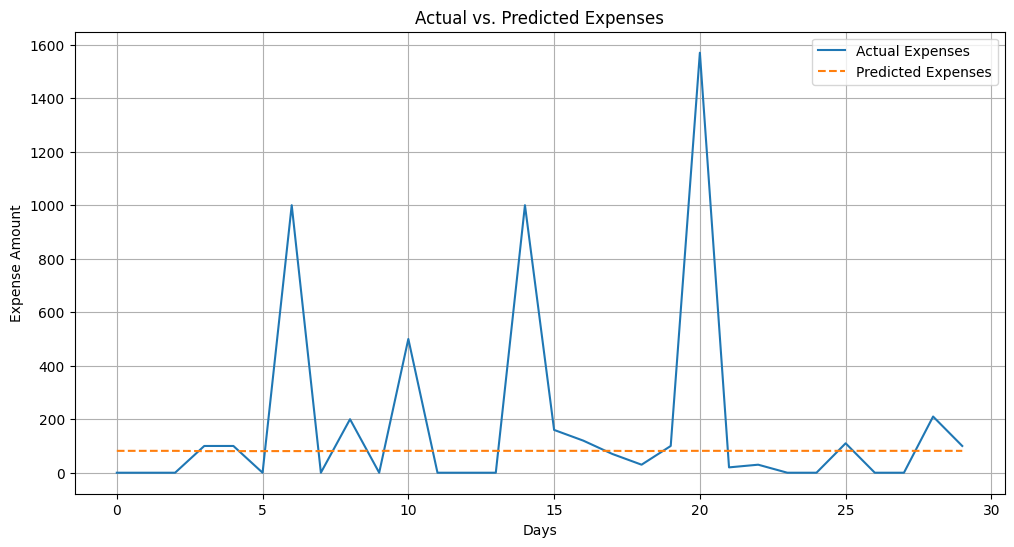

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten

# Function to create sequences
def create_sequence(data, window_size):
    data_np = data['Amount'].to_numpy()
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data_np[i-window_size:i])
        y.append(data_np[i])
    return np.array(X), np.array(y)

# Load preprocessed dataset
df = pd.read_excel('/content/Transformed_dataset_own.xlsx',
                   sheet_name="Sheet2 (Karish digital)")

df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + " " + df['Time'].astype(str))
df_expenses = df[df['Money flow'] == "Expense"]
df_expenses = df_expenses[['Datetime', 'Amount']]
df_expenses.set_index('Datetime', inplace=True)

# Resample for daily expense
daily_expense_df = df_expenses.resample('D').sum()

# Split data
split_index = int(0.8 * len(daily_expense_df))
train_daily_df = daily_expense_df[:split_index]
test_daily_df = daily_expense_df[split_index:]

# Define window size
window_size = 7

# Create sequences
X_train, y_train = create_sequence(train_daily_df, window_size)
X_test, y_test = create_sequence(test_daily_df, window_size)

# Reshape input for CNN (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN-LSTM Model
model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(window_size, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Predict
y_pred = model.predict(X_test)

import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual Expenses", linestyle='solid')
plt.plot(y_pred, label="Predicted Expenses", linestyle='dashed')
plt.xlabel("Days")
plt.ylabel("Expense Amount")
plt.title("Actual vs. Predicted Expenses")
plt.legend()
plt.grid()
plt.show()

# Hybrid CNN-Transformer

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - loss: 37189.9141 - val_loss: 161350.4531
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 26416.2793 - val_loss: 160302.7969
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 61026.1094 - val_loss: 159439.6406
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 43077.5547 - val_loss: 158656.5938
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 43114.9414 - val_loss: 157850.5312
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 41627.5508 - val_loss: 157019.0312
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 54588.0078 - val_loss: 156126.3438
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 37191.8984 - val_loss: 155164.5312
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 45263.3203 - val_loss: 154137.1719
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 58708.9609 - val_loss: 153079.9062
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 48717.593

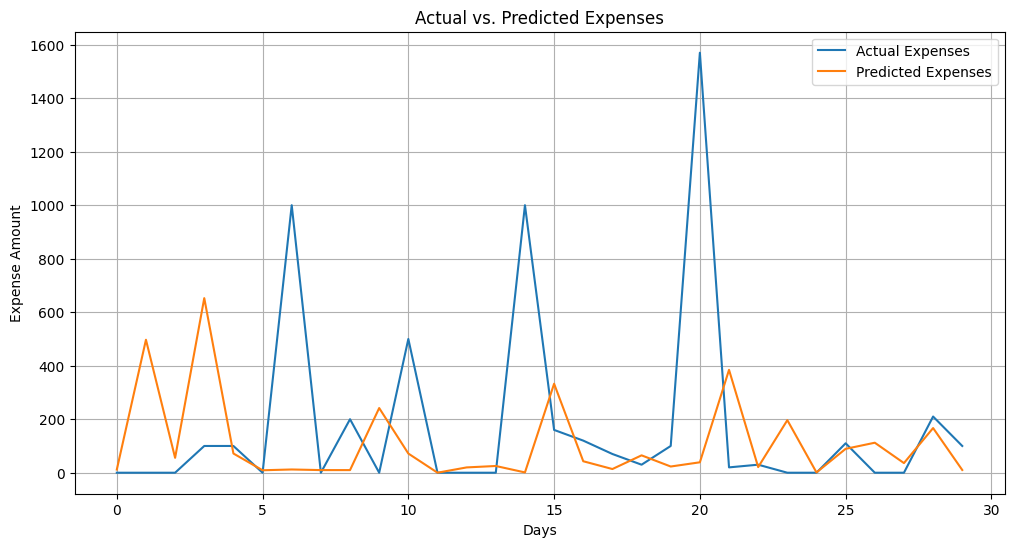

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LayerNormalization, MultiHeadAttention, Dropout, Add, Reshape, Lambda

# Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dense(inputs.shape[-1])(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x

# Input shape
inputs = Input(shape=(window_size, 1))

# CNN for feature extraction
x = Conv1D(filters=64, kernel_size=2, activation="relu")(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Flatten()(x)
x = Dense(64, activation="relu")(x)

# Reshape for transformer
x = Lambda(lambda t: tf.expand_dims(t, axis=1))(x)

# Transformer Encoder
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128)
x = Flatten()(x)
x = Dense(32, activation="relu")(x)
outputs = Dense(1)(x)

# Build model
model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

# Train model
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# Predict
y_pred = model.predict(X_test)

import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual Expenses", linestyle='solid')
plt.plot(y_pred, label="Predicted Expenses", linestyle='solid')
plt.xlabel("Days")
plt.ylabel("Expense Amount")
plt.title("Actual vs. Predicted Expenses")
plt.legend()
plt.grid()
plt.show()

# Moving Averages

MSE error for moving average prediction: 0.00017
Predicted Finance for Next Day: 65.86082510332749


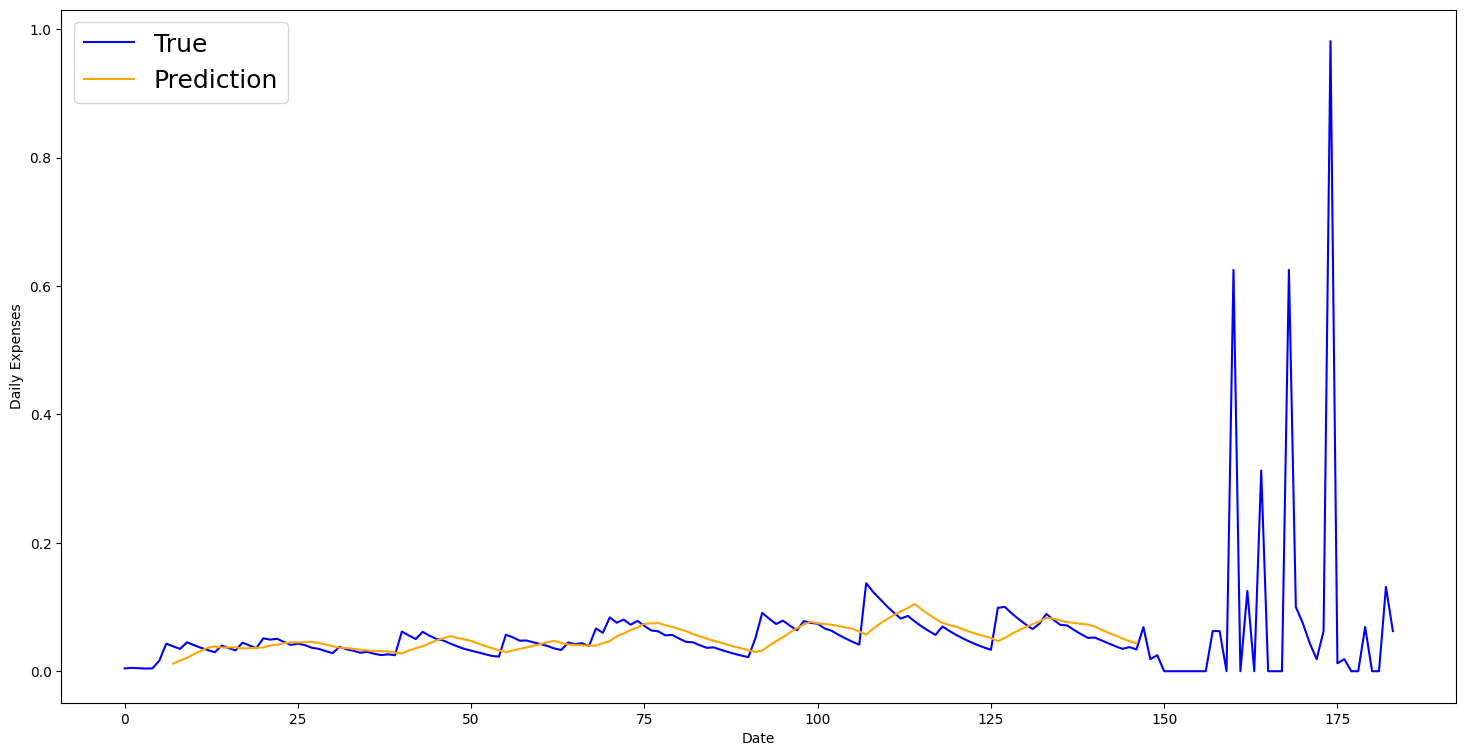

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_excel('/content/Transformed_dataset_own.xlsx', sheet_name="Sheet2 (Karish digital)")

# Preprocess datetime and extract expenses
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + " " + df['Time'].astype(str))
df_expenses = df[df['Money flow'] == "Expense"][['Datetime', 'Amount']].sort_values(by='Datetime')
df_expenses.set_index('Datetime', inplace=True)

# Resampling daily expenses
daily_expense_df = df_expenses.resample('D').sum()

# Splitting into training and testing data
split_index = int(0.8 * len(daily_expense_df))
train_daily_df = daily_expense_df[:split_index]
test_daily_df = daily_expense_df[split_index:]

# Scaling the data
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_daily_df)
test_data = scaler.transform(test_daily_df)

# Reshape train and test data
train_data = train_data.reshape(-1)
test_data = test_data.reshape(-1)

# Exponential Moving Average Smoothing
EMA = 0.0
gamma = 0.1
for ti in range(len(train_data)):
    EMA = gamma * train_data[ti] + (1 - gamma) * EMA
    train_data[ti] = EMA

# Concatenate all data
total_data = np.concatenate([train_data, test_data], axis=0)

# Moving average prediction
window_size = 7
N = train_data.size
predictions = []
mse_errors = []

for pred_idx in range(window_size, N):
    predictions.append(np.mean(train_data[pred_idx - window_size:pred_idx]))
    mse_errors.append((predictions[-1] - train_data[pred_idx]) ** 2)

print('MSE error for moving average prediction: %.5f' % (0.5 * np.mean(mse_errors)))

# Predict next day's finance based on moving average
next_day_prediction = np.mean(train_data[-window_size:])
next_day_prediction = scaler.inverse_transform([[next_day_prediction]])[0][0]

print(f'Predicted Finance for Next Day: {next_day_prediction}')

# Plot results
plt.figure(figsize=(18, 9))
plt.plot(range(len(total_data)), total_data, color='b', label='True')
plt.plot(range(window_size, N), predictions, color='orange', label='Prediction')
plt.xlabel('Date')
plt.ylabel('Daily Expenses')
plt.legend(fontsize=18)
plt.show()

<ipython-input-18-a0643445f64a>:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Datetime'])


MSE error for training data: 0.00007
MSE error for test data: 0.00333
🔮 Predicted Expense for Next Day: 115.57


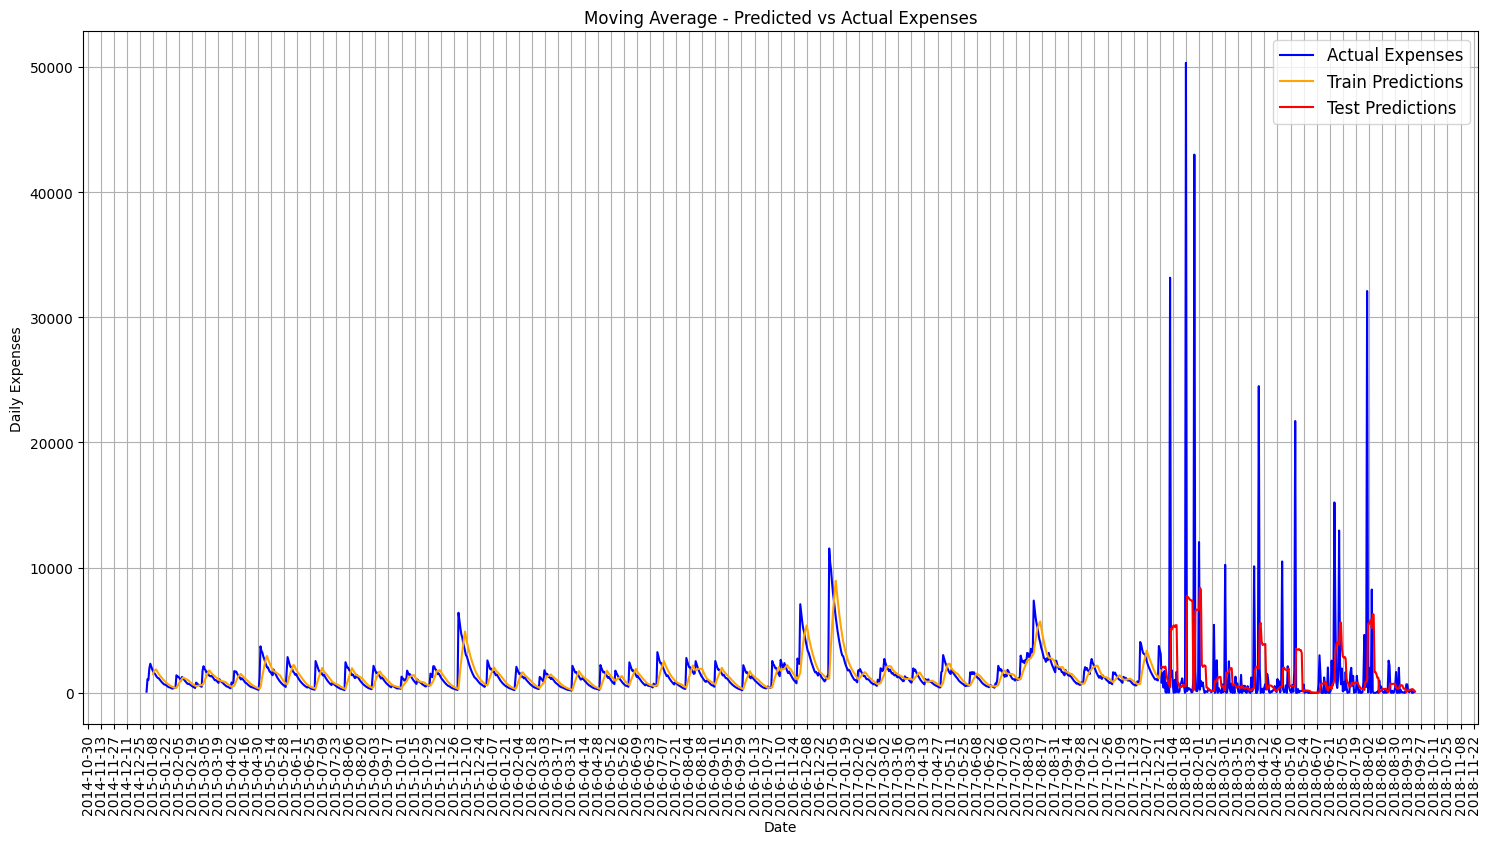

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv('/content/Daily_Household_Transactions.csv')

# Preprocess datetime and extract expenses
df = df.rename(columns={'Date': 'Datetime'})
df['Datetime'] = pd.to_datetime(df['Datetime'])
df_expenses = df[df['Income/Expense'] == "Expense"][['Datetime', 'Amount']].sort_values(by='Datetime')
df_expenses.set_index('Datetime', inplace=True)

# Resampling daily expenses
daily_expense_df = df_expenses.resample('D').sum()

# Splitting into training and testing data
split_index = int(0.8 * len(daily_expense_df))
train_daily_df = daily_expense_df[:split_index]
test_daily_df = daily_expense_df[split_index:]

# Scaling the data
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_daily_df)
test_data = scaler.transform(test_daily_df)

# Reshape train and test data
train_data = train_data.reshape(-1)
test_data = test_data.reshape(-1)

# Exponential Moving Average Smoothing on training data
EMA = 0.0
gamma = 0.1
for ti in range(len(train_data)):
    EMA = gamma * train_data[ti] + (1 - gamma) * EMA
    train_data[ti] = EMA

# Combine train and test data for full prediction
total_data = np.concatenate([train_data, test_data], axis=0)

# Moving Average Prediction
window_size = 7
N_train = train_data.size
N_total = total_data.size

train_predictions = []
test_predictions = []
mse_train_errors = []
mse_test_errors = []

# Predict on training data
for pred_idx in range(window_size, N_train):
    pred_value = np.mean(train_data[pred_idx - window_size:pred_idx])
    train_predictions.append(pred_value)
    mse_train_errors.append((pred_value - train_data[pred_idx]) ** 2)

# Predict on test data using sliding window (continuing from train data)
for pred_idx in range(N_train, N_total):
    pred_value = np.mean(total_data[pred_idx - window_size:pred_idx])
    test_predictions.append(pred_value)
    mse_test_errors.append((pred_value - total_data[pred_idx]) ** 2)

# Compute Mean Squared Errors
mse_train = np.mean(mse_train_errors)
mse_test = np.mean(mse_test_errors)

print(f'MSE error for training data: {mse_train:.5f}')
print(f'MSE error for test data: {mse_test:.5f}')

# Convert predictions back to original scale
train_predictions_rescaled = scaler.inverse_transform(np.array(train_predictions).reshape(-1, 1)).flatten()
test_predictions_rescaled = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1)).flatten()

# Rescale actual test values
test_actual_rescaled = scaler.inverse_transform(test_data.reshape(-1, 1)).flatten()

# Predict Next Day's Expense
next_day_prediction = np.mean(total_data[-window_size:])
next_day_prediction_rescaled = scaler.inverse_transform([[next_day_prediction]])[0][0]
print(f'🔮 Predicted Expense for Next Day: {next_day_prediction_rescaled:.2f}')

import matplotlib.dates as mdates

# Convert index to date format
dates = daily_expense_df.index

# Plot Results
plt.figure(figsize=(18, 9))
plt.plot(dates, scaler.inverse_transform(total_data.reshape(-1, 1)), color='blue', label='Actual Expenses')
plt.plot(dates[window_size:N_train], train_predictions_rescaled, color='orange', label='Train Predictions')
plt.plot(dates[N_train:], test_predictions_rescaled, color='red', label='Test Predictions')

# Formatting the x-axis to show only a few dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format date labels
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=14))  # Show dates every 10 days
plt.xticks(rotation=90)  # Rotate dates for better readability

plt.xlabel('Date')
plt.ylabel('Daily Expenses')
plt.legend(fontsize=12)
plt.title("Moving Average - Predicted vs Actual Expenses")
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 0.0097
Epoch [20/100], Loss: 0.0071
Epoch [30/100], Loss: 0.0074
Epoch [40/100], Loss: 0.0071
Epoch [50/100], Loss: 0.0071
Epoch [60/100], Loss: 0.0072
Epoch [70/100], Loss: 0.0071
Epoch [80/100], Loss: 0.0071
Epoch [90/100], Loss: 0.0074
Epoch [100/100], Loss: 0.0071


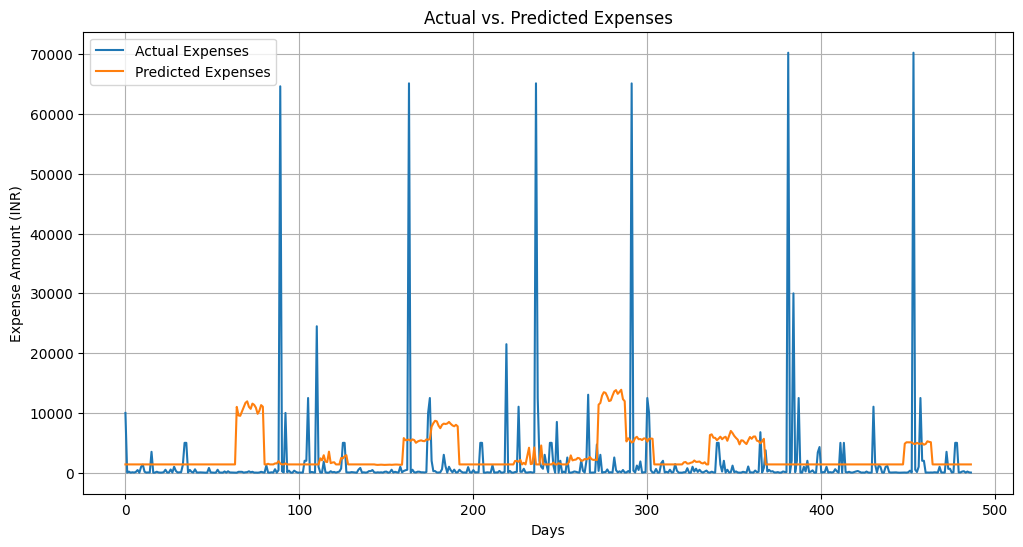

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("dataset_2.csv")  # Replace with actual file path

# Convert Date to datetime format and sort data
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")
df = df.sort_values(by="Date")

# Encode categorical variables (Mode, Category, Subcategory, Income/Expense)
label_encoders = {}
for col in ["Mode", "Category", "Subcategory", "Income/Expense"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for inverse transformation if needed

# Normalize 'Amount' using MinMaxScaler
scaler = MinMaxScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])  # Scale between 0 and 1

# Convert data into sequences for time-series forecasting
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i : i + window_size].values)  # Window of previous `window_size` entries
        y.append(data.iloc[i + window_size]["Amount"])  # Next day's expense
    return np.array(X), np.array(y)

# Define window size
window_size = 30  # Adjust based on how many previous days you want to use

# Create sequences
X, y = create_sequences(df[["Amount", "Mode", "Category", "Subcategory", "Income/Expense"]], window_size)

# Reshape for model input
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])  # Ensure it has shape (samples, time steps, features)

# Split into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Multi-head attention
        attn_output, _ = self.attention(x, x, x)
        x = x + self.dropout(attn_output)
        x = self.norm1(x)

        # Feed-forward network
        ff_output = self.ff(x)
        x = x + self.dropout(ff_output)
        x = self.norm2(x)

        return x

# CNN + Transformer Model
class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, ff_dim, window_size, dropout=0.1):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * (window_size // 2), 64),
            nn.ReLU(),
        )
        self.transformer = TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # CNN for feature extraction
        x = x.permute(0, 2, 1)  # Reshape for Conv1D: (batch, features, time steps)
        x = self.cnn(x)

        # Reshape for transformer
        x = x.unsqueeze(1)  # Add time step dimension: (batch, 1, features)

        # Transformer encoder
        x = self.transformer(x)

        # Fully connected layers
        x = x.squeeze(1)  # Remove time step dimension
        x = self.fc(x)

        return x

# Initialize model
input_dim = X.shape[2]  # Number of features
embed_dim = 64  # Embedding dimension for transformer
num_heads = 4  # Number of attention heads
ff_dim = 128  # Feed-forward dimension
model = CNNTransformerModel(input_dim, embed_dim, num_heads, ff_dim, window_size)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluation
model.eval()
y_pred = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model(batch_X)
        y_pred.extend(outputs.numpy())

# Inverse transform predictions and actual values to original scale
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))
y_pred_original = scaler.inverse_transform(np.array(y_pred).reshape(-1, 1))

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual Expenses", linestyle='solid')
plt.plot(y_pred_original, label="Predicted Expenses", linestyle='solid')
plt.xlabel("Days")
plt.ylabel("Expense Amount (INR)")
plt.title("Actual vs. Predicted Expenses")
plt.legend()
plt.grid()
plt.show()

Epoch 1, Loss: 0.0568
Epoch 11, Loss: 0.0345
Epoch 21, Loss: 0.0331
Epoch 31, Loss: 0.0296
Epoch 41, Loss: 0.0260
Epoch 51, Loss: 0.0214
Epoch 61, Loss: 0.0149
Epoch 71, Loss: 0.0114
Epoch 81, Loss: 0.0085
Epoch 91, Loss: 0.0076
MAE: 2.0071, R² Score: -0.8405


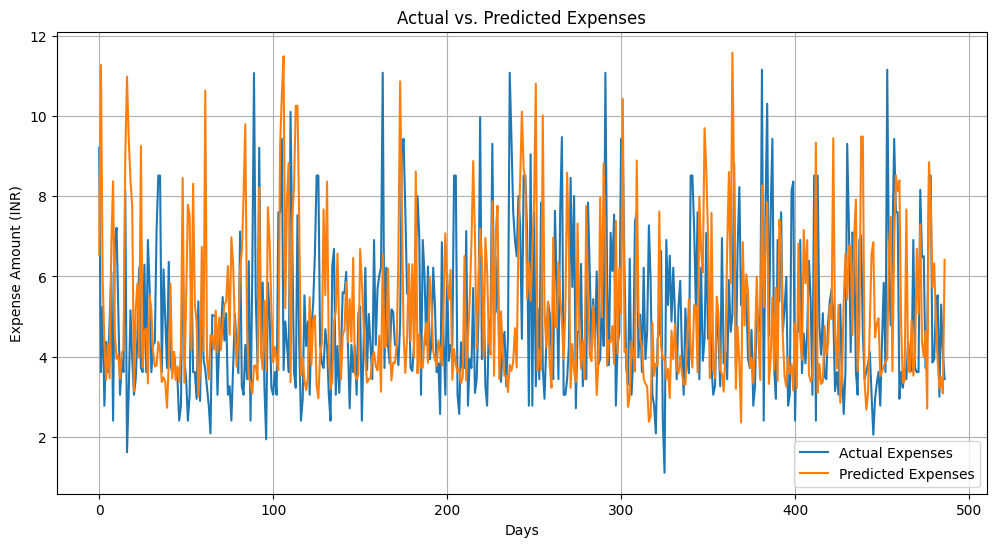

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("dataset_2.csv")  # Replace with actual file path
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")
df = df.sort_values(by="Date")

# Encode categorical variables
label_encoders = {}
for col in ["Mode", "Category", "Subcategory", "Income/Expense"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Log transformation to reduce outliers
df["Amount"] = np.log1p(df["Amount"])

# Normalize 'Amount'
scaler = MinMaxScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

# Function to create sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i : i + window_size].values)
        y.append(data.iloc[i + window_size]["Amount"])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(df[["Amount", "Mode", "Category", "Subcategory", "Income/Expense"]], window_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Convert to PyTorch tensors
X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)

# DataLoader
train_dataset, test_dataset = TensorDataset(X_train, y_train), TensorDataset(X_test, y_test)
train_loader, test_loader = DataLoader(train_dataset, batch_size=32, shuffle=True), DataLoader(test_dataset, batch_size=32, shuffle=False)

# Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

# Enhanced CNN + Transformer Model
class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, ff_dim, window_size, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * (window_size // 2), 64),
            nn.ReLU(),
        )
        self.transformer = nn.Sequential(
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout),
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
        )
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        x = self.fc(x)
        return x

# Initialize model
input_dim = X.shape[2]
model = CNNTransformerModel(input_dim, embed_dim=64, num_heads=4, ff_dim=128, window_size=window_size)

# Loss, Optimizer, and Scheduler
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training loop with early stopping
early_stopping_threshold = 5
best_loss = float('inf')
stopping_counter = 0

for epoch in range(100):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    lr_scheduler.step()
    avg_loss = total_loss / len(train_loader)
    if epoch%10 == 0:
          print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    if avg_loss < best_loss:
        best_loss = avg_loss
        stopping_counter = 0
    else:
        stopping_counter += 1
    if stopping_counter >= early_stopping_threshold:
        print("Early stopping triggered")
        break

# Evaluation
model.eval()
y_pred = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model(batch_X)
        y_pred.extend(outputs.numpy())

# Inverse transform
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))
y_pred_original = scaler.inverse_transform(np.array(y_pred).reshape(-1, 1))

# Metrics
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)
print(f"MAE: {mae:.4f}, R² Score: {r2:.4f}")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual Expenses")
plt.plot(y_pred_original, label="Predicted Expenses")
plt.xlabel("Days")
plt.ylabel("Expense Amount (INR)")
plt.title("Actual vs. Predicted Expenses")
plt.legend()
plt.grid()
plt.show()

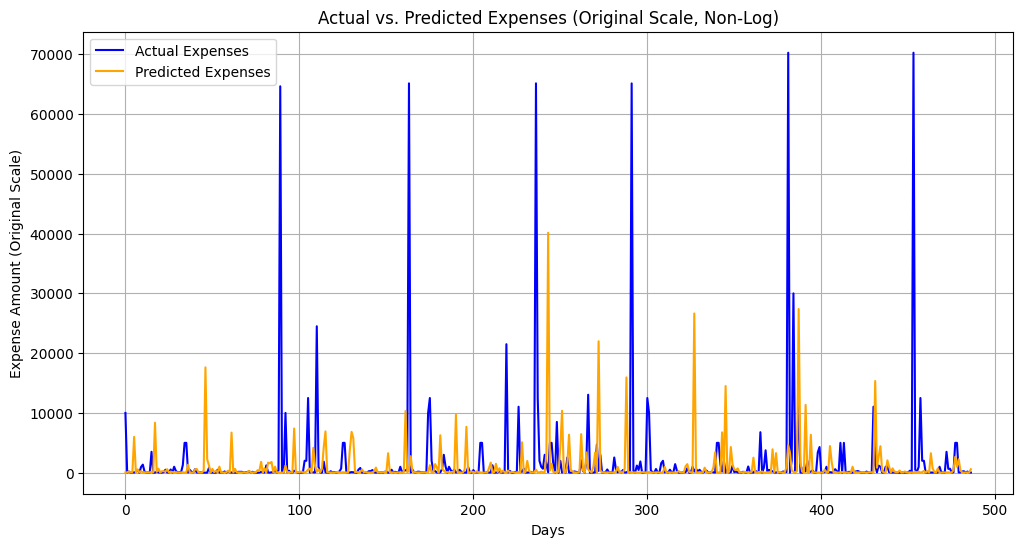

In [ ]:
# If log transformation was applied before scaling, revert it using exponential function
y_test_original = np.exp(y_test_original)
y_pred_original = np.exp(y_pred_original)

# Plot actual vs predicted values in original scale
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual Expenses", linestyle='solid', color='blue')
plt.plot(y_pred_original, label="Predicted Expenses", linestyle='solid', color='orange')
plt.xlabel("Days")
plt.ylabel("Expense Amount (Original Scale)")
plt.title("Actual vs. Predicted Expenses (Original Scale, Non-Log)")
plt.legend()
plt.grid()
plt.show()


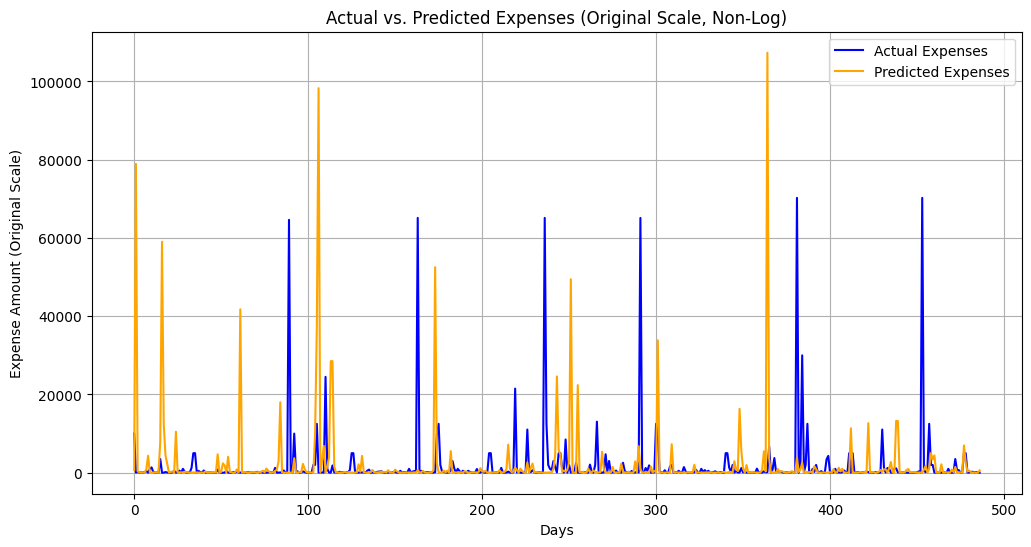

In [ ]:
# If log transformation was applied before scaling, revert it using exponential function
y_test_original = np.exp(y_test_original)
y_pred_original = np.exp(y_pred_original)

# Plot actual vs predicted values in original scale
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual Expenses", linestyle='solid', color='blue')
plt.plot(y_pred_original, label="Predicted Expenses", linestyle='solid', color='orange')
plt.xlabel("Days")
plt.ylabel("Expense Amount (Original Scale)")
plt.title("Actual vs. Predicted Expenses (Original Scale, Non-Log)")
plt.legend()
plt.grid()
plt.show()
